# Uncertainty at the input: adaptive precisions

The deep learning notebooks ([deep learning](./0.7-Deep_learning.ipynb),
[transformers](./0.8-Transformers.ipynb)) run the deep predictive coding
network in its pinned-confidence configuration: the precisions are frozen so
that the weight updates coincide with backpropagation. This notebook does the
opposite. It leaves the framework's dynamic precision updates on and asks what
the precisions of the activations do during learning, and what the network's
input uncertainty controls.

With the volatility levels off (`volatility_parent=False`), interior nodes
have no volatility source, so the network's uncertainty budget is set
entirely at its boundaries: the predictor (input) layer's precision
$\pi_x$, which states how much the network trusts the values clamped on
$x$, and the observed output layer's prior precision, which states how
sharply $y$ is observed. This notebook varies the input side and measures
four things:

1. **Propagation**: how $\pi_x$ enters the interior layers' expected
   precisions, with the closed form to check against.
2. **Mean invariance**: the forward pass returns the same expected means for
   every $\pi_x$; precision shapes learning, not the prediction.
3. **Learning modulation**: under stochastic gradient descent the
   precision-weighted updates scale with input trust, including a stability
   boundary where distrusted inputs make learning diverge.
4. **Adaptive precision dynamics**: with the confidence updates on, the
   interior precisions accumulate evidence across batches, at a rate set by
   $\pi_x$, and the accumulation stalls once the prediction errors vanish.


In [1]:
import jax
import matplotlib.pyplot as plt
import numpy as np
import optax
import seaborn as sns

from pyhgf.model import DeepNetwork

plt.rcParams["figure.constrained_layout.use"] = True
rng = np.random.default_rng(3)

## 1. A network with one uncertainty dial

The running example is a `8 <- 32 <- 16` regression network: input layer of
16 nodes, one hidden layer of 32, output layer of 8. Layers are declared
bottom (output) first, and every layer is built without a volatility level.
The input layer's `precision` and `expected_precision` are set to $\pi_x$;
the interior and output layers keep the default prior precision of 1.

The task is a linear map $y = A x$, observed through noisy inputs
$x_{\mathrm{obs}} = x + \sigma\,\varepsilon$: the declared input
precision $\pi_x$ and the true input noise $\sigma$ are then two sides of
the same quantity, one believed, one real.

In [2]:
SIZES = [8, 32, 16]  # bottom (output) first


def build(pi_x, seed=7):
    """A deep network whose input layer carries precision ``pi_x``."""
    net = DeepNetwork()
    net.add_layer(size=SIZES[0], volatility_parent=False)
    net.add_layer(size=SIZES[1], volatility_parent=False)
    net.add_layer(
        size=SIZES[2],
        volatility_parent=False,
        precision=pi_x,
        expected_precision=pi_x,
    )
    net.weight_initialisation("he", key=jax.random.key(seed))
    return net


A = rng.normal(scale=0.4, size=(8, 16)).astype("float32")
x_test = rng.normal(size=(512, 16)).astype("float32")
y_test = x_test @ A.T


def batch(n, sigma=0.0):
    x_clean = rng.normal(size=(n, 16)).astype("float32")
    x_obs = x_clean + sigma * rng.normal(size=(n, 16)).astype("float32")
    return x_obs, x_clean @ A.T

## 2. How input uncertainty propagates

A prediction sweep sends $\pi_x$ into the hidden layer through the Laplace
value-coupling correction: linearising the coupling function at the parent's
expected mean and marginalising over the parent's Gaussian adds, per hidden
node $i$, the variance $\sum_j W_{ij}^2\, t^2 / \hat{\pi}_{x,j}$, so

$$\frac{1}{\hat{\pi}_i} \;=\; \frac{1}{\pi_i^{\mathrm{prior}}}
\;+\; \sum_j \frac{W_{ij}^2\, t^2}{\pi_x}.$$

Trusted inputs (large $\pi_x$) leave the hidden layer's expected precision
at its prior; distrusted inputs dilute it. The constant bias parent has
infinite precision and contributes nothing. The observed output layer is a
leaf: its expected precision stays at its own prior and does not inherit the
hidden layer's uncertainty.

measured hidden expected precisions match the closed form


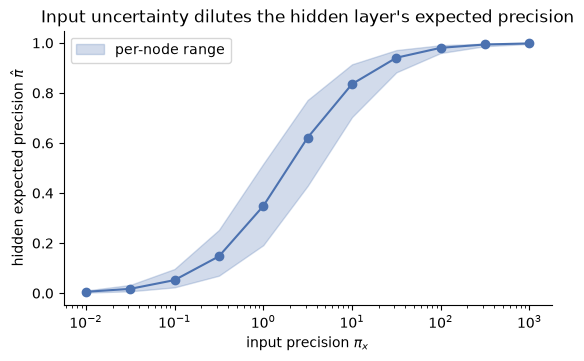

In [3]:
pi_grid = np.logspace(-2, 3, 11)
measured = []
for pi_x in pi_grid:
    net = build(float(pi_x))
    net.prediction(x_test[0])
    hidden = np.asarray(net.state.layers[1].state.expected_precision)
    # Closed form from the same weights. A layer's ``weights_in`` is the
    # matrix predicting its child below, so the input-to-hidden weights live
    # on the input layer; the trailing bias column is excluded (the constant
    # parent has infinite precision).
    w = np.asarray(net.state.layers[2].weights_in)[:, :-1]
    closed = 1.0 / (1.0 + (w**2).sum(axis=1) / pi_x)
    np.testing.assert_allclose(hidden, closed, rtol=1e-5)
    measured.append(hidden)
measured = np.array(measured)

fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.plot(pi_grid, measured.mean(axis=1), marker="o", color="#4c72b0")
ax.fill_between(
    pi_grid, measured.min(axis=1), measured.max(axis=1),
    alpha=0.25, color="#4c72b0", label="per-node range",
)
ax.set(
    xscale="log", xlabel=r"input precision $\pi_x$",
    ylabel=r"hidden expected precision $\hat{\pi}$",
    title="Input uncertainty dilutes the hidden layer's expected precision",
)
ax.legend()
sns.despine()
print("measured hidden expected precisions match the closed form")

The forward pass itself does not depend on $\pi_x$: the expected means
are matrix products of expected means, and precision enters neither. Two
networks with identical weights and input precisions three orders of
magnitude apart return bitwise identical predictions.

In [4]:
low, high = build(0.1), build(100.0)
d = np.abs(np.asarray(low.predict(x_test)) - np.asarray(high.predict(x_test))).max()
print(f"max |predict(pi_x = 0.1) - predict(pi_x = 100)| = {d:.2e}")
assert d == 0.0

max |predict(pi_x = 0.1) - predict(pi_x = 100)| = 0.00e+00


## 3. Input trust modulates learning

Where $\pi_x$ does act is the update sweep. A low input precision makes the
hidden layer's expected precision small, and a belief held with little
precision is moved far by its prediction errors: the precision-weighted
updates, and with them the weight gradients, grow as the inputs are
trusted less. Under stochastic gradient descent with a fixed learning rate,
$\pi_x$ therefore behaves like an inverse learning-rate dial, with a
stability boundary: at a learning rate where trusted inputs converge
quickly, distrusted inputs diverge.

The confidence updates stay on throughout (`update_confidences=True`, the
default), so these runs are the framework's native regime, not the pinned
one.

lr 0.05, pi_x =   0.1: diverged
lr 0.05, pi_x =   1.0: diverged
lr 0.05, pi_x =  10.0: MSE 0.0000
lr 0.05, pi_x = 100.0: MSE 0.0000


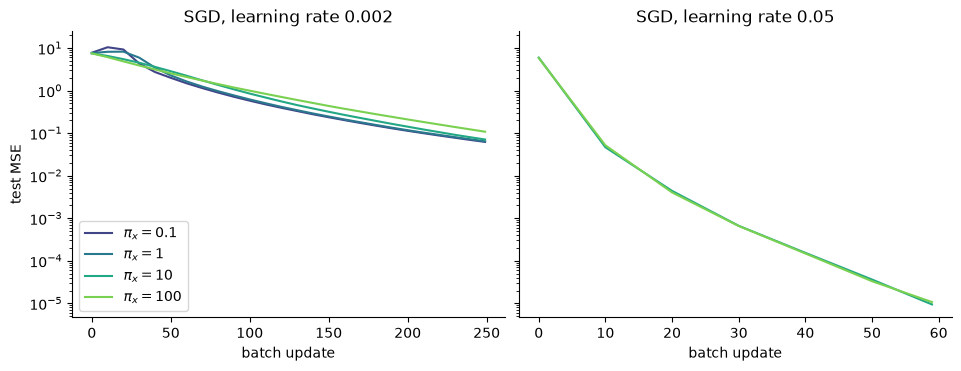

In [5]:
def train(pi_x, lr, n_steps, sigma=0.0, optimizer="sgd", record_every=10):
    """Train against ``y = A x`` and record test error and hidden precision."""
    net = build(pi_x)
    opt = optax.sgd(lr) if optimizer == "sgd" else optax.adam(lr)
    steps, mses, precisions, input_errors = [], [], [], []
    for step in range(n_steps):
        x_obs, y_obs = batch(128, sigma)
        net.batch_update(x_obs, y_obs, optimizer=opt)
        if step % record_every == 0 or step == n_steps - 1:
            steps.append(step)
            pred = np.asarray(net.predict(x_test))
            # A diverged run overflows float32 here; the resulting inf/nan is
            # the honest reading, so the overflow is expected, not an error.
            with np.errstate(over="ignore", invalid="ignore"):
                mses.append(float(((pred - y_test) ** 2).mean()))
            precisions.append(
                float(np.asarray(net.state.layers[1].state.precision).mean())
            )
            input_errors.append(float(np.abs(np.asarray(net.input_errors)).mean()))
    return {
        "steps": np.array(steps), "mse": np.array(mses),
        "precision": np.array(precisions), "input_error": np.array(input_errors),
    }


PI_GRID = [0.1, 1.0, 10.0, 100.0]
palette = {pi: c for pi, c in zip(PI_GRID, sns.color_palette("viridis", len(PI_GRID)))}

runs_stable = {pi: train(pi, lr=2e-3, n_steps=250) for pi in PI_GRID}
runs_fast = {pi: train(pi, lr=5e-2, n_steps=60) for pi in PI_GRID}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.5, 3.6), sharey=True)
for pi in PI_GRID:
    ax1.plot(runs_stable[pi]["steps"], runs_stable[pi]["mse"],
             color=palette[pi], label=rf"$\pi_x = {pi:g}$")
    ax2.plot(runs_fast[pi]["steps"], runs_fast[pi]["mse"], color=palette[pi])
ax1.set(
    yscale="log", xlabel="batch update", ylabel="test MSE",
    title="SGD, learning rate 0.002",
)
ax2.set(xlabel="batch update", title="SGD, learning rate 0.05", yscale="log")
ax1.legend()
sns.despine()
for pi in PI_GRID:
    final = runs_fast[pi]["mse"][-1]
    outcome = "diverged" if not np.isfinite(final) else f"MSE {final:.4f}"
    print(f"lr 0.05, pi_x = {pi:>5}: {outcome}")

## 4. The precisions of the activations learn

With the confidence updates on, every batch adds its mean precision
increment to the hidden layer's carried belief: the network accumulates
evidence about its own activations. Two properties of that accumulation are
worth seeing.

First, the rate follows input trust: trusted inputs make sharper hidden
predictions, whose posterior updates add more precision per batch.

Second, the accumulation is evidence driven, so it limits itself. On a task
the network solves, the prediction errors vanish and the precision
trajectory flattens; under persistent input noise the errors never vanish
and precision keeps growing. There is no volatility level here to leak
precision away, so information only ever accumulates; a volatility parent is
exactly what would give these beliefs a forgetting rate.

The precision-weighted prediction errors routed to the input layer
(`input_errors`, the message a stacked pipeline would propagate upstream)
shrink correspondingly: the same annealing, seen from the messages.

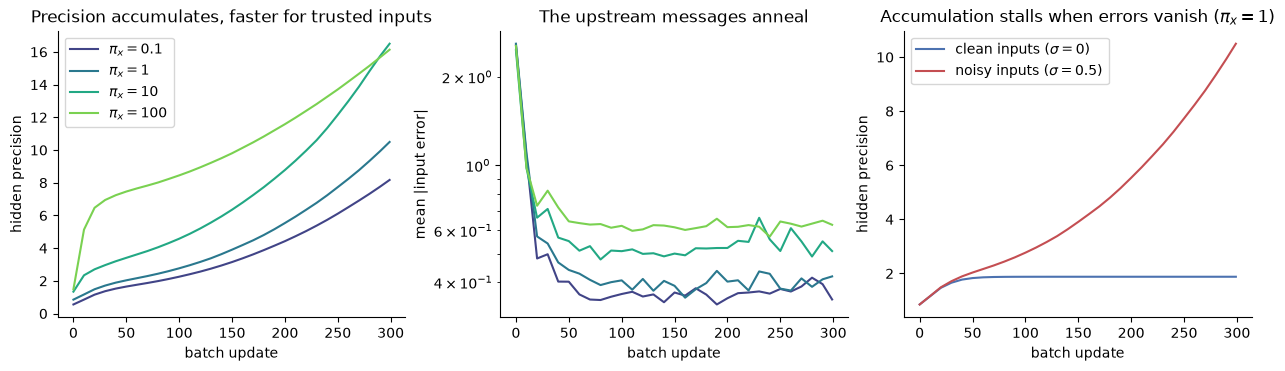

In [6]:
runs_noisy = {pi: train(pi, lr=1e-2, n_steps=300, sigma=0.5, optimizer="adam")
              for pi in PI_GRID}
run_clean = train(1.0, lr=1e-2, n_steps=300, sigma=0.0, optimizer="adam")

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12.5, 3.6))
for pi in PI_GRID:
    ax1.plot(runs_noisy[pi]["steps"], runs_noisy[pi]["precision"],
             color=palette[pi], label=rf"$\pi_x = {pi:g}$")
    ax2.plot(runs_noisy[pi]["steps"], runs_noisy[pi]["input_error"],
             color=palette[pi])
ax1.set(
    xlabel="batch update", ylabel="hidden precision",
    title="Precision accumulates, faster for trusted inputs",
)
ax2.set(
    xlabel="batch update", ylabel="mean |input error|", yscale="log",
    title="The upstream messages anneal",
)
ax3.plot(run_clean["steps"], run_clean["precision"],
         color="#4c72b0", label=r"clean inputs ($\sigma = 0$)")
ax3.plot(runs_noisy[1.0]["steps"], runs_noisy[1.0]["precision"],
         color="#c44e52", label=r"noisy inputs ($\sigma = 0.5$)")
ax3.set(
    xlabel="batch update", ylabel="hidden precision",
    title=r"Accumulation stalls when errors vanish ($\pi_x = 1$)",
)
ax1.legend()
ax3.legend()
sns.despine()

## 5. Reading the results

- **One dial, two regimes.** The input precision leaves the forward map
  untouched and acts entirely through the update sweep: it is a statement
  about how far incoming evidence should move the beliefs, not about what
  the network predicts.
- **Trust as a learning rate.** Under plain gradient descent, distrusting
  the inputs amplifies the precision-weighted updates, to the point of
  instability; trusting them keeps the updates small and stable. Adaptive
  optimisers such as Adam normalise each coordinate's gradient scale, so
  they absorb most of this global effect; the modulation is a property of
  the precision-weighted messages, which is where a pipeline built on these
  messages would feel it.
- **Learnt confidences.** The interior precisions are the part of the
  network that learns beyond the weights: they integrate the evidence each
  batch provides, faster when the inputs are trusted, and stop when there is
  no error left to explain. Under persistent noise they grow without bound,
  because nothing here forgets; adding a volatility parent to a layer is the
  framework's way of giving its precisions a leak, which is the natural next
  experiment.
- **Relation to the pinned regime.** The
  [transformer notebook](./0.8-Transformers.ipynb) freezes exactly the
  quantities this notebook lets move, which is what aligns the weight
  updates with backpropagation. The two regimes are ends of one axis:
  pinning buys gradient equivalence, adaptivity buys uncertainty tracking.
